### **Training**

#### K-Fold cross validation

- (solves not enough data problem)
- you are using K different models to be trained (each fold uses a different model)
- might be time consuming
- error: average the errors of different models 

#### Parameters

- 调参数 = 模型自己学习
- 调超参数 = 你通过验证集来选择和优化设置

#### Overfitting vs Underfitting
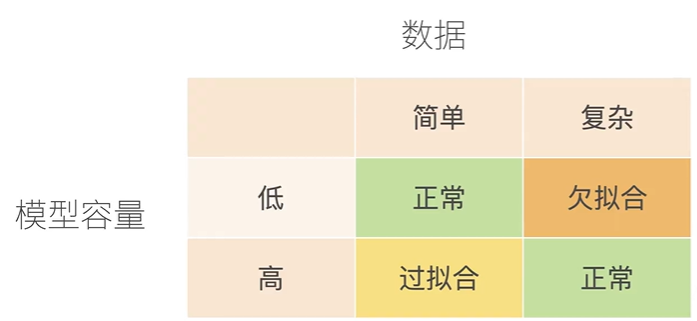 

<img src="./pictures/image0.png" width="300">
<img src="./pictures/image2.png" width="320">

#### Regularization / Weight Decay


min $l(w, b) + \frac{\lambda}{2} |w|^2$

- to control the parameters to within a range
- if $\lambda$ = 0: regularization term does not apply
- if $\lambda$ = $\infty$: w* -> 0

<img src="./pictures/image3.png" width="320">

- the $n$ is to make $w_t$ gradually decrease and contained within itself so it doesn't blow up

In [ ]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss()
    num_epochs, lr = 100, 0.003
    trainer = torch.optim.SGD([{
                "params": net[0].weight, 
                'weight_decay': wd}, {"params": net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log', xlim=[5, num_epochs], legend=['train', 'test'])

    for epoch in range(num_epochs):
        for X, y in train_iter:
            with torch.enable_grad():
                trainer.zero_grad()
                l = loss(net(X), y)
            l.backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss), d2l.evaluate_loss(net, test_iter, loss)))

#### Drop Out

- add noise to the data and drop out some other data
- we want the noised data (x') to have the same $E[x']=x$
- drop out rate (p) where you just throw away things
- the ones where you kept follows the rules below

<img src="./pictures/image4.png" width="320">

- often used in hidden layers

<img src="./pictures/image5.png" width="700">

- drop out is only used in training
- during inference (testing), drop out will return itself
- $h = dropout(h)$
- to regulate the complexity of the model

**Common dropout rate: 0.5, 0.9**

### **CNN**

#### Introduction to CNN

<img src="./pictures/l046_image1.png" width="500">
<img src="./pictures/l046_image2.png" width="510">

<img src="./pictures/l046_image3.png" width="300">
<img src="./pictures/l046_image4.png" width="480">

 <img src="./pictures/l046_image5.png" width="500">

#### Padding

 <img src="./pictures/l049_image1.png" width="400">
  <img src="./pictures/l049_image2.png" width="660">

 <img src="./pictures/l049_image3.png" width="450">

#### Steps

 <img src="./pictures/l049_image4.png" width="500">

  <img src="./pictures/l049_image5.png" width="500">

 <img src="./pictures/l049_image6.png" width="500">

#### multiple channels

<img src="./pictures/l051_image1.png" width="500">

<img src="./pictures/l051_image2.png" width="500">

<img src="./pictures/l051_image3.png" width="500">

multiple input channels are usually after getting multiple output channels. They take these outputs (e.g. lines, stripes, edge detection) and determine which one is more important and how to combine them to identify more macroscopic features

<img src="./pictures/l051_image4.png" width="500">

#### Pooling Layer

<image src="pictures/l053_image1.png" width="600">

<image src="pictures/l053_image2.png" width="400">

<image src="pictures/l053_image3.png" width="500">

#### LeNet

<image src="pictures/l055_image1.png" alt="LeNet" width="900">

<image src="pictures/l055_image2.png" width="500">